# WUPP4
This notebook mirrors the **WUPP v2.0** ArcPy workflow as closely as practical in pure Python.

## 1) Imports and environment

In [5]:
### Assumes installs

from pathlib import Path
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling
import geopandas as gpd
import heapq
import math


## 2) Set file paths and parameters

In [6]:
\
# --- Inputs ---
bp_path = Path(r"C:\Users\9k3\OneDrive - Oak Ridge National Laboratory\NAERM\Wildfire_Melissa\WUPP_Toolbox_and_Inputs\WUPP_Toolbox_and_Inputs\State_BPs\Tennessee_BP.tif")          # BurnProbability_Input
ign_path = Path(r"C:\Users\9k3\OneDrive - Oak Ridge National Laboratory\NAERM\Wildfire_Melissa\WUPP2_Toolbox_and_Inputs\WUPP2_Toolbox_and_Inputs\ignition_chimneytops\Ignition_chimneytops_prj.shp")         # Ignition_Input
wind_path = Path(r"C:\Users\9k3\OneDrive - Oak Ridge National Laboratory\NAERM\Wildfire_Melissa\WUPP2_Toolbox_and_Inputs\WUPP2_Toolbox_and_Inputs\wspd_rast\wspd_11231620_alb.tif")             # WindSpeed_Input (raster)
sp_path = Path(r"C:\Users\9k3\OneDrive - Oak Ridge National Laboratory\NAERM\Wildfire_Melissa\WUPP2_Toolbox_and_Inputs\WUPP2_Toolbox_and_Inputs\sp_rast\sp_alb_raster.tif")         # SurfacePressure_Input (raster)
regions_path = Path(r"C:\Users\9k3\OneDrive - Oak Ridge National Laboratory\NAERM\Wildfire_Melissa\WUPP_Toolbox_and_Inputs\WUPP_Toolbox_and_Inputs\Clim_Regions_TN\Tennessee_Climate.shp")            # Region_Input (polygons)

# Field on regions used to name outputs (Region_Field in ArcPy)
region_name_field = "NAME"  

# --- Parameters ---
exclude_zero = True          # ExcludeZero parameter
hours_to_burn = 0.25          # HoursToBurn_Input
cell_size_m_assumed = 270.0  # WUPP2 assumes 270m cells in the distance formula

# --- Outputs ---
outputs_dir = Path(r"C:\Users\9k3\Desktop\WUPP3\WUPP_PyPort\Outputs")
outputs_dir.mkdir(parents=True, exist_ok=True)


## 3) Load datasets and align CRS

In [7]:
# Load BP raster metadata (grid definition)
with rasterio.open(bp_path) as src:
    bp = src.read(1)
    bp_meta = src.meta.copy()
    bp_crs = src.crs
    bp_transform = src.transform
    bp_nodata = src.nodata
    bp_shape = (src.height, src.width)

# Load wind and surface pressure rasters (should match BP grid)
with rasterio.open(wind_path) as src:
    wind = src.read(1)
    wind_meta = src.meta.copy()
with rasterio.open(sp_path) as src:
    sp = src.read(1)
    sp_meta = src.meta.copy()

# Load ignition points and regions
ign_gdf = gpd.read_file(ign_path)
reg_gdf = gpd.read_file(regions_path)

if ign_gdf.crs is None:
    raise ValueError("Ignition file has no CRS.")
if reg_gdf.crs is None:
    raise ValueError("Regions file has no CRS.")
if bp_crs is None:
    raise ValueError("BP raster has no CRS.")

# Reproject vectors to BP CRS
ign_gdf = ign_gdf.to_crs(bp_crs)
reg_gdf = reg_gdf.to_crs(bp_crs)

'''# Grid consistency checks (WUPP2 assumes rasters are aligned)
def _check_grid(meta, name):
    if meta["crs"] != bp_crs:
        raise ValueError(f"{name} CRS != BP CRS. Warp {name} to match BP.")
    if meta["transform"] != bp_transform or meta["width"] != bp_meta["width"] or meta["height"] != bp_meta["height"]:
        raise ValueError(f"{name} grid != BP grid (transform/shape mismatch). Warp {name} to BP grid.")

_check_grid(wind_meta, "WindSpeed raster")
_check_grid(sp_meta, "SurfacePressure raster")

print("Loaded. BP shape:", bp_shape, "CRS:", bp_crs)'''


'# Grid consistency checks (WUPP2 assumes rasters are aligned)\ndef _check_grid(meta, name):\n    if meta["crs"] != bp_crs:\n        raise ValueError(f"{name} CRS != BP CRS. Warp {name} to match BP.")\n    if meta["transform"] != bp_transform or meta["width"] != bp_meta["width"] or meta["height"] != bp_meta["height"]:\n        raise ValueError(f"{name} grid != BP grid (transform/shape mismatch). Warp {name} to BP grid.")\n\n_check_grid(wind_meta, "WindSpeed raster")\n_check_grid(sp_meta, "SurfacePressure raster")\n\nprint("Loaded. BP shape:", bp_shape, "CRS:", bp_crs)'

In [ ]:
### Warp winspeed and surface pressure to BP grid if needed (WUPP2 assumes grids aligned)
def warp_to_bp_grid(src_path, bp_meta, resampling):
    """Reproject/resample an input raster to match BP grid exactly (CRS+transform+shape)."""
    with rasterio.open(src_path) as src:
        dst = np.empty((bp_meta["height"], bp_meta["width"]), dtype="float32")

        reproject(
            source=rasterio.band(src, 1),
            destination=dst,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=bp_meta["transform"],
            dst_crs=bp_meta["crs"],
            dst_nodata=np.nan,
            resampling=resampling,
        )
    return dst

# Wind speed: continuous -> bilinear
wind_bpgrid = warp_to_bp_grid(wind_path, bp_meta, Resampling.bilinear)

# Surface pressure: continuous -> bilinear
sp_bpgrid = warp_to_bp_grid(sp_path, bp_meta, Resampling.bilinear)

print("Aligned arrays:", wind_bpgrid.shape, sp_bpgrid.shape)
print("Wind stats:", float(np.nanmin(wind_bpgrid)), float(np.nanmean(wind_bpgrid)), float(np.nanmax(wind_bpgrid)))
print("SP stats:", float(np.nanmin(sp_bpgrid)), float(np.nanmean(sp_bpgrid)), float(np.nanmax(sp_bpgrid)))


Aligned arrays: (1001, 2930) (1001, 2930)
Wind stats: 1.2689067125320435 3.123628616333008 4.427567958831787
SP stats: 88612.4296875 95530.859375 99833.03125


## 4) Preprocess rasters 
Implements the WUPP2 math:
- `pctBurnRaster = BP * 100`
- If ExcludeZero: keep only >0 (else treat as 0)
- `sfc_pres = SP * 1e-7`
- `invDemand = 1_000_000 where burnRaster==0 else (1/burnRaster)*sfc_pres`


In [10]:
# Convert fractional burn probability to percent (ArcPy: Raster(BP)*100)
burn_pct = bp.astype("float32") * 100.0

# Treat nodata/invalid as 0 for the burnRaster (ArcGIS masking is handled later by region masking)
invalid_bp = ~np.isfinite(burn_pct)
if bp_nodata is not None:
    invalid_bp |= (bp == bp_nodata)
burn_pct[invalid_bp] = 0.0

if bool(exclude_zero):
    burnRaster = np.where(burn_pct > 0, burn_pct, 0.0).astype("float32")
else:
    burnRaster = burn_pct.astype("float32")

# Surface pressure scaling (ArcPy: Raster(SP)*0.0000001)
sfc_pres = sp_bpgrid.astype("float32") * 1e-7

# invDemand (ArcPy Con with where_clause VALUE=0):
# where burnRaster==0 -> 1,000,000 else (1/burnRaster)*sfc_pres
invDemand = np.where(burnRaster == 0.0, 1_000_000.0, (1.0 / burnRaster) * sfc_pres).astype("float32")

print("burnRaster (pct) stats:", float(np.min(burnRaster)), float(np.mean(burnRaster)), float(np.max(burnRaster)))
print("sfc_pres stats:", float(np.nanmin(sfc_pres)), float(np.nanmean(sfc_pres)), float(np.nanmax(sfc_pres)))
print("invDemand stats:", float(np.min(invDemand)), float(np.mean(invDemand)), float(np.max(invDemand)))


burnRaster (pct) stats: 0.0 0.04419796168804169 3.004000186920166
sfc_pres stats: 0.008861242793500423 0.009553086012601852 0.009983303025364876
invDemand stats: nan nan nan


C:\Users\9k3\AppData\Local\Temp\ipykernel_2568\2724693064.py:2: RuntimeWarning: overflow encountered in multiply
  burn_pct = bp.astype("float32") * 100.0
C:\Users\9k3\AppData\Local\Temp\ipykernel_2568\2724693064.py:20: RuntimeWarning: divide by zero encountered in divide
  invDemand = np.where(burnRaster == 0.0, 1_000_000.0, (1.0 / burnRaster) * sfc_pres).astype("float32")


## 5) Compute spread limit
ArcPy uses the **maximum windspeed** in the wind raster:
`Maximum_Distance = max_wspd * 0.1 * hours * 3600 / 270` (cells)


In [11]:
wind_f = wind_bpgrid.astype("float32")
wind_invalid = ~np.isfinite(wind_f)
if wind_meta.get("nodata", None) is not None:
    wind_invalid |= (wind_f == wind_meta["nodata"])
wind_f = np.where(wind_invalid, -np.inf, wind_f)

max_wspd = float(np.max(wind_f))
Maximum_Distance = max_wspd * 0.1 * float(hours_to_burn) * 3600.0 / float(cell_size_m_assumed)

print("max_wspd (m/s):", max_wspd)
print("Maximum_Distance (cells):", Maximum_Distance)


max_wspd (m/s): 4.427567958831787
Maximum_Distance (cells): 1.4758559862772624


## 6) Core solver: raster least-cost expansion (Dijkstra)
Analogue of ArcGIS CostDistance/CostAllocation.

Faithfulness choice:
- Treat `invDemand` as per-cell movement cost.
- Move cost = `step_cells * avg(cost_from, cost_to)`.
- Budget is in **cells** (matching WUPP2's division by 270).


In [12]:
def dijkstra_cost_reach(inv_cost, start_rcs, budget_cells, blocked=None, use_8_neighbor=True):
    """Return a uint8 mask of reachable cells within accumulated cost budget."""
    H, W = inv_cost.shape
    if blocked is None:
        blocked = np.zeros((H, W), dtype=bool)

    # ensure seeds are not blocked
    for (r, c) in start_rcs:
        if 0 <= r < H and 0 <= c < W:
            blocked[r, c] = False

    dist = np.full((H, W), np.inf, dtype="float64")
    pq = []
    for (r, c) in start_rcs:
        if 0 <= r < H and 0 <= c < W and not blocked[r, c]:
            dist[r, c] = 0.0
            heapq.heappush(pq, (0.0, r, c))

    if not pq:
        return np.zeros((H, W), dtype=np.uint8)

    moves4 = [(-1, 0, 1.0), (1, 0, 1.0), (0, -1, 1.0), (0, 1, 1.0)]
    sqrt2 = math.sqrt(2.0)
    moves8 = moves4 + [(-1, -1, sqrt2), (-1, 1, sqrt2), (1, -1, sqrt2), (1, 1, sqrt2)]
    moves = moves8 if use_8_neighbor else moves4

    reached = np.zeros((H, W), dtype=np.uint8)

    while pq:
        d, r, c = heapq.heappop(pq)
        if d != dist[r, c]:
            continue
        if d > budget_cells:
            continue

        reached[r, c] = 1
        c_cost = float(inv_cost[r, c])

        for dr, dc, step in moves:
            rr = r + dr
            cc = c + dc
            if rr < 0 or rr >= H or cc < 0 or cc >= W:
                continue
            if blocked[rr, cc]:
                continue

            n_cost = float(inv_cost[rr, cc])
            edge_cost = step * (c_cost + n_cost) / 2.0
            nd = d + edge_cost

            if nd < dist[rr, cc] and nd <= budget_cells:
                dist[rr, cc] = nd
                heapq.heappush(pq, (nd, rr, cc))

    return reached


## 7) Per-region run

In [13]:
from rasterio.transform import rowcol

def rasterize_polygon_mask(poly_geom, meta):
    out_shape = (meta["height"], meta["width"])
    arr = rasterize(
        [(poly_geom, 1)],
        out_shape=out_shape,
        transform=meta["transform"],
        fill=0,
        dtype="uint8",
        all_touched=False,
    )
    return arr.astype(bool)

def points_to_seed_cells(points_gdf, transform, shape):
    seeds = []
    for geom in points_gdf.geometry:
        if geom is None or geom.is_empty:
            continue
        pt = geom if geom.geom_type == "Point" else geom.centroid
        r, c = rowcol(transform, pt.x, pt.y)
        if 0 <= r < shape[0] and 0 <= c < shape[1]:
            seeds.append((int(r), int(c)))
    return seeds

def write_u8_raster(path, arr_u8, meta):
    out_meta = meta.copy()
    out_meta.update(dtype="uint8", count=1, nodata=0)
    with rasterio.open(path, "w", **out_meta) as dst:
        dst.write(arr_u8.astype("uint8"), 1)

results = []
for idx, row in reg_gdf.iterrows():
    reg_name = str(row.get(region_name_field, f"region_{idx}"))
    safe_name = "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in reg_name)[:80]

    geom = row.geometry
    if geom is None or geom.is_empty:
        continue

    ign_in = ign_gdf[ign_gdf.intersects(geom)]
    if len(ign_in) == 0:
        print(f"[{safe_name}] No ignitions in region; skipping")
        continue

    region_mask = rasterize_polygon_mask(geom, bp_meta)      # True inside region
    blocked = ~region_mask                                   # Block outside region

    seeds = points_to_seed_cells(ign_in, bp_transform, bp_shape)
    if not seeds:
        print(f"[{safe_name}] Ignitions could not be mapped to raster cells; skipping")
        continue

    burned = dijkstra_cost_reach(invDemand, seeds, Maximum_Distance, blocked=blocked, use_8_neighbor=True)

    out_raster = outputs_dir / f"{safe_name}_burnmask_wupp2b.tif"
    write_u8_raster(out_raster, burned, bp_meta)
    results.append((safe_name, str(out_raster), int(burned.sum())))

    print(f"[{safe_name}] burned cells: {int(burned.sum())} → {out_raster}")

results


[WESTERN] No ignitions in region; skipping
[MIDDLE] No ignitions in region; skipping
[CUMBERLAND_PLATEAU] No ignitions in region; skipping
[EASTERN] burned cells: 5310 → C:\Users\9k3\Desktop\WUPP3\WUPP_PyPort\Outputs\EASTERN_burnmask_wupp2b.tif


[('EASTERN',
  'C:\\Users\\9k3\\Desktop\\WUPP3\\WUPP_PyPort\\Outputs\\EASTERN_burnmask_wupp2b.tif',
  5310)]

## 8) Optional quick plot (not required)

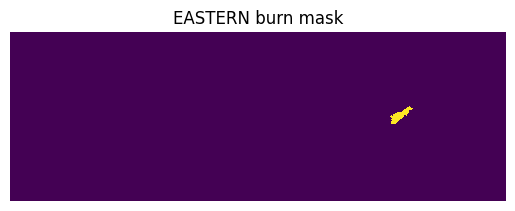

In [14]:
import matplotlib.pyplot as plt

def quick_plot(mask_u8, title="burn mask"):
    plt.figure()
    plt.imshow(mask_u8, interpolation="nearest")
    plt.title(title)
    plt.axis("off")
    plt.show()

if len(results) > 0:
    last = results[-1]
    with rasterio.open(last[1]) as src:
        arr = src.read(1)
    quick_plot(arr, title=f"{last[0]} burn mask")
